# Patient Journey Analysis

**Author:** Your Name  
**Date:** generated when cells are run


In [4]:
# Libraries
missing_required = []
for package_name, import_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("statsmodels", "statsmodels"),
    ("geopandas", "geopandas"),
]:
    try:
        __import__(import_name)
    except ImportError:
        missing_required.append(package_name)

if missing_required:
    raise ImportError(
        "Missing required Python packages: "
        + ", ".join(missing_required)
        + "\nInstall them in this notebook kernel with: %pip install "
        + " ".join(missing_required)
        + "\nThen restart or rerun this cell."
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from IPython.display import display, Markdown

import statsmodels.formula.api as smf
HAS_STATSMODELS = True

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

print({
    "pandas": pd.__version__,
    "statsmodels_available": HAS_STATSMODELS,
})


{'pandas': '3.0.1', 'statsmodels_available': True}


# 1. Big Picture

The goal of this analysis is to understand **what factors influence how a patient moves through the healthcare system**, from admission to discharge, and to identify opportunities to improve the patient journey.

**Five analytical pillars:**

- **Demographics** - Who is the patient?
- **Geography** - Where do they live?
- **Behavioral/Social** - Smoking status and marital status
- **Clinical Context** - Visit type and admission type
- **Providers** - Who is treating them?


# 2. Data Structure

In [5]:
# Load data from CSV files
# Read only the columns used in this notebook so the large CSVs load faster.
def read_csv_fast(path, usecols=None, **kwargs):
    return pd.read_csv(path, usecols=usecols, low_memory=False, **kwargs)

encounter_cols = [
    "Date", "AdmissionInstant", "AdmissionSource", "AdmissionType",
    "DischargeInstant", "EncounterKey", "PatientDurableKey", "Type",
    "VisitType", "VisitTypeDescription", "DepartmentKey", "PrimaryDiagnosisKey",
    "IsEdVisit", "IsHospitalAdmission", "IsHospitalOutpatientVisit",
    "IsInpatientAdmission", "IsObservation", "IsOutpatientFaceToFaceVisit",
]
patient_cols = [
    "CensusBlockGroupFipsCode", "DurableKey", "FirstRace", "MaritalStatus",
    "MyChartStatus", "OmbEthnicity", "OmbRace", "SexAssignedAtBirth",
    "SexualOrientation", "SmokingStatus", "VitalStatus", "PatientBirthYearBin",
]
diagnosis_cols = ["DiagnosisKey", "DiagnosisValue"]
provider_cols = None  # Loaded for parity with the original workflow; not used downstream.
social_cols = ["AnswerText", "EncounterKey", "PatientDurableKey", "Domain"]
department_cols = ["DepartmentKey", "DepartmentName", "DepartmentSpecialty", "DepartmentType", "CensusTract"]
tiger_cols = ["GEOID", "PopulationValue", "CENTLAT", "CENTLON"]

# CSV files are in the parent directory
encounters = read_csv_fast("../encounters.csv")
patients = read_csv_fast("../patients.csv")
diagnosis = read_csv_fast("../diagnosis.csv")
providers = pd.DataFrame()  # providers.csv is not used by the translated analysis
social_determinants = read_csv_fast("../social_determinants.csv")
departments = read_csv_fast("../departments.csv")
tigercensuscodes = read_csv_fast("../tigercensuscodes.csv", usecols=tiger_cols)

print("Loaded CSV files directly with selected columns.")
print({
    "encounters": encounters.shape,
    "patients": patients.shape,
    "diagnosis": diagnosis.shape,
    "providers": providers.shape,
    "social_determinants": social_determinants.shape,
    "departments": departments.shape,
    "tigercensuscodes": tigercensuscodes.shape,
})

Loaded CSV files directly with selected columns.
{'encounters': (7675801, 31), 'patients': (947685, 12), 'diagnosis': (1531262, 5), 'providers': (0, 0), 'social_determinants': (3977901, 5), 'departments': (11597, 9), 'tigercensuscodes': (2463, 4)}


In [6]:
# Data structure quick look
# Uses a small sample for missing counts so this cell stays responsive on large CSVs.
def glimpse(df, name, sample_rows=10_000):
    print(f"\n{name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
    display(df.head())

    sample = df.head(min(sample_rows, len(df)))
    structure = pd.DataFrame({
        "column": df.columns,
        "dtype": [df[c].dtype for c in df.columns],
        f"missing_in_first_{len(sample):,}_rows": [sample[c].isna().sum() for c in df.columns],
    })
    display(structure.head(40))

glimpse(encounters, "encounters")
glimpse(patients, "patients")
glimpse(departments, "departments")



encounters: 7,675,801 rows x 31 columns


,Date,AdmissionInstant,AdmitYear,AdmitMonth,AdmitDay,AdmitHour,AdmitMinute,AdmissionSource,AdmissionType,DischargeInstant,DischargeYear,DischargeMonth,DischargeDay,DischargeHour,DischargeMinute,EncounterKey,PatientDurableKey,Type,VisitType,VisitTypeDescription,ProviderDurableKey,AttendingProviderDurableKey,DischargeProviderDurableKey,DepartmentKey,PrimaryDiagnosisKey,IsEdVisit,IsHospitalAdmission,IsHospitalOutpatientVisit,IsInpatientAdmission,IsObservation,IsOutpatientFaceToFaceVisit
0,04/25/22,2022-04-25 20:33:00,2022.0,4.0,25.0,20.0,33.0,Non-Health Care Facility Point of Origin,Elective,2022-04-25 21:35:00,2022.0,4.0,25.0,21.0,35.0,7848127,86333,Hospital Encounter,*Unspecified,*Unspecified,2982,2982,2982,27,910699,0,1,0,0,1,0
1,04/29/22,2022-04-29 18:18:00,2022.0,4.0,29.0,18.0,18.0,Clinic/Physician Referral,Elective,2022-04-29 18:20:00,2022.0,4.0,29.0,18.0,20.0,9333470,626973,Hospital Encounter,*Unspecified,*Unspecified,2979,2979,2979,27,-1,0,1,0,0,1,0
2,01/10/22,2022-01-10 05:52:00,2022.0,1.0,10.0,5.0,52.0,Non-Health Care Facility Point of Origin,Elective,2022-01-12 11:43:00,2022.0,1.0,12.0,11.0,43.0,29444575,236044,Hospital Encounter,*Unspecified,*Unspecified,6223,6223,7015,27,468738,0,1,0,1,0,0
3,03/08/22,2022-03-08 09:08:00,2022.0,3.0,8.0,9.0,8.0,Non-Health Care Facility Point of Origin,Elective,2022-03-10 13:45:00,2022.0,3.0,10.0,13.0,45.0,30915704,385246,Hospital Encounter,*Unspecified,*Unspecified,7973,7973,7973,27,468492,0,1,0,1,0,0
4,03/16/22,2022-03-16 14:19:00,2022.0,3.0,16.0,14.0,19.0,Non-Health Care Facility Point of Origin,Elective,2022-03-16 16:00:00,2022.0,3.0,16.0,16.0,0.0,33223911,353096,Hospital Encounter,*Unspecified,*Unspecified,6223,6223,2982,27,907210,0,1,0,0,1,0


,column,dtype,"missing_in_first_10,000_rows"
0,Date,str,0
1,AdmissionInstant,str,9980
2,AdmitYear,float64,9980
3,AdmitMonth,float64,9980
4,AdmitDay,float64,9980
5,AdmitHour,float64,9980
6,AdmitMinute,float64,9980
7,AdmissionSource,str,0
8,AdmissionType,str,0
9,DischargeInstant,str,9980



patients: 947,685 rows x 12 columns


,CensusBlockGroupFipsCode,DurableKey,FirstRace,MaritalStatus,MyChartStatus,OmbEthnicity,OmbRace,SexAssignedAtBirth,SexualOrientation,SmokingStatus,VitalStatus,PatientBirthYearBin
0,201770007002,5.0,White or Caucasian,Single,Activated,Not Hispanic or Latino,White,*Unspecified,*Unspecified,Never,Alive,1970.0
1,*Unspecified,8.0,White or Caucasian,*Unspecified,Inactivated,Unknown,White,*Unspecified,*Unspecified,*Unknown,Alive,1980.0
2,*Unspecified,9.0,"Hispanic, Latino, or Spanish",Married,*Unspecified,Unknown,Some Other Race,*Unspecified,*Unspecified,Never,Alive,1955.0
3,*Unspecified,11.0,"Hispanic, Latino, or Spanish",Unknown,*Unspecified,Hispanic or Latino,Some Other Race,*Unspecified,*Unspecified,Never,Alive,1970.0
4,*Unspecified,12.0,Black or African American,Single,*Unspecified,Not Hispanic or Latino,Black or African American,*Unspecified,*Unspecified,Never,Alive,1980.0


,column,dtype,"missing_in_first_10,000_rows"
0,CensusBlockGroupFipsCode,str,0
1,DurableKey,float64,0
2,FirstRace,str,1479
3,MaritalStatus,str,0
4,MyChartStatus,str,0
5,OmbEthnicity,str,0
6,OmbRace,str,0
7,SexAssignedAtBirth,str,0
8,SexualOrientation,str,0
9,SmokingStatus,str,0



departments: 11,597 rows x 9 columns


,DepartmentKey,Address,City,County,DepartmentName,DepartmentSpecialty,DepartmentType,PostalCode,CensusTract
0,-3,*Deleted,*Deleted,*Deleted,*Deleted,*Deleted,*Deleted,*Deleted,NaN
1,-2,*Not Applicable,*Not Applicable,*Not Applicable,*Not Applicable,*Not Applicable,*Not Applicable,*Not Applicable,NaN
2,-1,*Unspecified,*Unspecified,*Unspecified,*Unspecified,*Unspecified,*Unspecified,*Unspecified,NaN
3,1,1500 SW 10th ST,TOPEKA,*Unspecified,INITIAL DEPT,*Unspecified,*Unknown,66604,2.017700e+10
4,2,1979 Milky Way,VERONA,*Unspecified,EHS UM DEPT,*Unspecified,*Unknown,53593,5.502501e+10


,column,dtype,"missing_in_first_10,000_rows"
0,DepartmentKey,int64,0
1,Address,str,2286
2,City,str,1606
3,County,str,569
4,DepartmentName,str,0
5,DepartmentSpecialty,str,569
6,DepartmentType,str,569
7,PostalCode,str,2411
8,CensusTract,float64,3787


# 3. Data Preparation

## 3.1 Date Conversions

In [7]:
# Date conversions
encounters_raw = encounters.copy()
encounters_raw["Date"] = pd.to_datetime(encounters_raw["Date"], errors="coerce").dt.date
encounters_raw["AdmissionInstant"] = pd.to_datetime(encounters_raw["AdmissionInstant"], errors="coerce")
encounters_raw["DischargeInstant"] = pd.to_datetime(encounters_raw["DischargeInstant"], errors="coerce")
encounters_raw["dateGap"] = (encounters_raw["DischargeInstant"] - encounters_raw["AdmissionInstant"]).dt.total_seconds() / 3600
encounters_raw["dateGapDays"] = encounters_raw["dateGap"] / 24

summary = pd.DataFrame({
    "encounters": [len(encounters_raw)],
    "missing_dateGap": [encounters_raw["dateGap"].isna().sum()],
    "mean_dateGap_hours": [round(encounters_raw["dateGap"].mean(skipna=True), 1)],
    "median_dateGap_hours": [round(encounters_raw["dateGap"].median(skipna=True), 1)],
})
display(summary)


/var/folders/rw/x_8mkzmx6cv46sdqwtbf0bch0000gn/T/ipykernel_1583/467249083.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  encounters_raw["Date"] = pd.to_datetime(encounters_raw["Date"], errors="coerce").dt.date


,encounters,missing_dateGap,mean_dateGap_hours,median_dateGap_hours
0,7675801,6627642,17.4,10.6


## 3.2 Merge Encounters, Patients, Diagnosis, Departments, and Social Data

In [8]:
# Merge data
def clean_fips(value, width=None):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    text = "".join(ch for ch in text if ch.isdigit())
    if not text:
        return pd.NA
    return text.zfill(width) if width else text

social_summary = (
    social_determinants
    .groupby(["EncounterKey", "PatientDurableKey"], dropna=False)
    .agg(
        social_domains=("Domain", lambda s: "; ".join(sorted(s.dropna().astype(str).unique()))),
        social_answers=("AnswerText", lambda s: "; ".join(sorted(s.dropna().astype(str).unique()))),
    )
    .reset_index()
)

mergeEncountersPatients = (
    encounters_raw
    .merge(patients, left_on="PatientDurableKey", right_on="DurableKey", how="left")
    .merge(diagnosis, left_on="PrimaryDiagnosisKey", right_on="DiagnosisKey", how="left")
    .merge(departments, on="DepartmentKey", how="left")
    .merge(social_summary, on=["EncounterKey", "PatientDurableKey"], how="left")
)

mergeEncountersPatients["ageDiff"] = 2026 - pd.to_numeric(mergeEncountersPatients["PatientBirthYearBin"], errors="coerce")
fips = mergeEncountersPatients["CensusBlockGroupFipsCode"].map(lambda x: clean_fips(x))
mergeEncountersPatients["state_fips"] = fips.str.slice(0, 2)
mergeEncountersPatients["county_fips"] = fips.str.slice(0, 5)
mergeEncountersPatients["CensusTract"] = fips.str.slice(0, 11).str.zfill(11)

preview_cols = [
    "EncounterKey", "PatientDurableKey", "Date", "dateGap", "dateGapDays",
    "AdmissionSource", "AdmissionType", "VisitType", "IsEdVisit",
    "FirstRace", "OmbRace", "MaritalStatus", "SmokingStatus", "VitalStatus",
    "PatientBirthYearBin", "ageDiff", "DiagnosisValue", "DepartmentName",
    "CensusBlockGroupFipsCode", "CensusTract",
]
existing_preview_cols = [c for c in preview_cols if c in mergeEncountersPatients.columns]
glimpse(mergeEncountersPatients[existing_preview_cols], "mergeEncountersPatients preview")



mergeEncountersPatients preview: 8,099,023 rows x 20 columns


,EncounterKey,PatientDurableKey,Date,dateGap,dateGapDays,AdmissionSource,AdmissionType,VisitType,IsEdVisit,FirstRace,OmbRace,MaritalStatus,SmokingStatus,VitalStatus,PatientBirthYearBin,ageDiff,DiagnosisValue,DepartmentName,CensusBlockGroupFipsCode,CensusTract
0,7848127,86333,2022-04-25,1.033333,0.043056,Non-Health Care Facility Point of Origin,Elective,*Unspecified,0,White or Caucasian,White,Single,Former,Alive,1995.0,31.0,O26.893,BIRTHPLACE,201770031002,20177003100
1,9333470,626973,2022-04-29,0.033333,0.001389,Clinic/Physician Referral,Elective,*Unspecified,0,White or Caucasian,White,Single,Former,Alive,1990.0,36.0,NaN,BIRTHPLACE,201770041004,20177004100
2,29444575,236044,2022-01-10,53.850000,2.243750,Non-Health Care Facility Point of Origin,Elective,*Unspecified,0,White or Caucasian,White,Married,Never,Alive,1985.0,41.0,O34.211,BIRTHPLACE,*Unspecified,NaN
3,30915704,385246,2022-03-08,52.616667,2.192361,Non-Health Care Facility Point of Origin,Elective,*Unspecified,0,"Hispanic, Latino, or Spanish",Two or More Races,Married,Never,Alive,1985.0,41.0,O14.04,BIRTHPLACE,201770013002,20177001300
4,33223911,353096,2022-03-16,1.683333,0.070139,Non-Health Care Facility Point of Origin,Elective,*Unspecified,0,American Indian or Alaska Native,American Indian or Alaska Native,Married,Every Day,Alive,1985.0,41.0,O09.30,BIRTHPLACE,*Unspecified,NaN


,column,dtype,"missing_in_first_10,000_rows"
0,EncounterKey,int64,0
1,PatientDurableKey,int64,0
2,Date,object,0
3,dateGap,float64,9980
4,dateGapDays,float64,9980
5,AdmissionSource,str,0
6,AdmissionType,str,0
7,VisitType,str,0
8,IsEdVisit,int64,0
9,FirstRace,str,441


## 3.3 Duplicate Handling

In [9]:
# Duplicate handling
duplicate_count = (
    mergeEncountersPatients
    .groupby(["PatientDurableKey", "EncounterKey", "DiagnosisValue"], dropna=False)
    .size()
    .reset_index(name="n")
    .query("n > 1")
    .shape[0]
)
print(f"Duplicate PatientDurableKey/EncounterKey/DiagnosisValue groups: {duplicate_count:,}")

mergeEncountersPatients = mergeEncountersPatients.drop_duplicates(
    subset=["PatientDurableKey", "EncounterKey", "DiagnosisValue"],
    keep="first",
)


Duplicate PatientDurableKey/EncounterKey/DiagnosisValue groups: 0


## 3.4 Diagnosis Flag

In [10]:
# Diagnosis flag
diagnosis_text = mergeEncountersPatients["DiagnosisValue"].fillna("").astype(str).str.lower()
mergeEncountersPatients["has_diabetes_encounter"] = diagnosis_text.str.contains(r"diabetes|e10|e11", regex=True)
mergeEncountersPatients["has_diabetes"] = mergeEncountersPatients.groupby("PatientDurableKey")["has_diabetes_encounter"].transform("any")

display(mergeEncountersPatients["has_diabetes"].value_counts(dropna=False).rename_axis("has_diabetes").reset_index(name="n"))


,has_diabetes,n
0,False,8099023


## 3.5 Vital Status Flag

In [11]:
# Vital status flag
mergeEncountersPatients["is_alive"] = mergeEncountersPatients["VitalStatus"].eq("Alive")
mergeEncountersPatients["is_deceased"] = mergeEncountersPatients["VitalStatus"].eq("Deceased")

display(
    mergeEncountersPatients
    .groupby(["VitalStatus", "is_alive"], dropna=False)
    .size()
    .reset_index(name="n")
)


,VitalStatus,is_alive,n
0,Alive,True,7488538
1,Deceased,False,274571
2,NaN,False,335914


## 3.6 Geography and Region Type

In [12]:
# Geography and region type
tiger = tigercensuscodes.copy()
tiger["CensusTract"] = tiger["GEOID"].map(lambda x: clean_fips(x, width=12)).str.slice(0, 11).str.zfill(11)
tiger["block_group"] = tiger["GEOID"].map(lambda x: clean_fips(x, width=12))
for col in ["PopulationValue", "CENTLAT", "CENTLON"]:
    tiger[col] = pd.to_numeric(tiger[col], errors="coerce")

def weighted_mean(group, value_col, weight_col):
    values = group[value_col]
    weights = group[weight_col]
    mask = values.notna() & weights.notna() & (weights > 0)
    if not mask.any():
        return np.nan
    return np.average(values[mask], weights=weights[mask])

tract_population = (
    tiger
    .groupby("CensusTract", dropna=False)
    .apply(lambda g: pd.Series({
        "total_population": g["PopulationValue"].sum(skipna=True),
        "CENTLAT": weighted_mean(g, "CENTLAT", "PopulationValue"),
        "CENTLON": weighted_mean(g, "CENTLON", "PopulationValue"),
    }))
    .reset_index()
)

conditions = [
    tract_population["total_population"] <= 500,
    tract_population["total_population"] <= 2000,
    tract_population["total_population"] > 2000,
]
choices = ["Rural", "Suburban", "Urban"]
tract_population["region_type"] = np.select(conditions, choices, default="Unknown")

mergeEncountersPatients = mergeEncountersPatients.merge(tract_population, on="CensusTract", how="left")
display(mergeEncountersPatients["region_type"].value_counts(dropna=False).rename_axis("region_type").reset_index(name="n"))


,region_type,n
0,Urban,5796223
1,NaN,2238517
2,Suburban,64238
3,Rural,45


## 3.7 Journey Score

In [13]:
# Journey score
def scale_inverse(series):
    x = pd.to_numeric(series, errors="coerce")
    xmin, xmax = x.min(skipna=True), x.max(skipna=True)
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmax == xmin:
        return pd.Series(np.nan, index=series.index)
    return 1 - (x - xmin) / (xmax - xmin)

def bool_series(series):
    if series.dtype == bool:
        return series
    return series.astype(str).str.lower().map({"true": True, "false": False, "1": True, "0": False})

mergeEncountersPatients["dateGap_scaled"] = scale_inverse(mergeEncountersPatients["dateGap"])
mergeEncountersPatients["ageDiff_scaled"] = scale_inverse(mergeEncountersPatients["ageDiff"])
mergeEncountersPatients["IsEdVisit_bool"] = bool_series(mergeEncountersPatients["IsEdVisit"])
mergeEncountersPatients["ed_scaled"] = np.where(mergeEncountersPatients["IsEdVisit_bool"].isna(), np.nan, np.where(mergeEncountersPatients["IsEdVisit_bool"], 0, 1))
mergeEncountersPatients["vital_scaled"] = np.where(mergeEncountersPatients["VitalStatus"].isna(), np.nan, np.where(mergeEncountersPatients["VitalStatus"].eq("Alive"), 1, 0))
mergeEncountersPatients["journey_score"] = (
    mergeEncountersPatients["dateGap_scaled"] * 0.30
    + mergeEncountersPatients["ageDiff_scaled"] * 0.25
    + mergeEncountersPatients["ed_scaled"] * 0.25
    + mergeEncountersPatients["vital_scaled"] * 0.20
).round(3)

journey_summary = pd.DataFrame({
    "rows": [len(mergeEncountersPatients)],
    "mean_journey_score": [round(mergeEncountersPatients["journey_score"].mean(skipna=True), 3)],
    "median_journey_score": [round(mergeEncountersPatients["journey_score"].median(skipna=True), 3)],
    "missing_journey_score": [mergeEncountersPatients["journey_score"].isna().sum()],
})
display(journey_summary)


,rows,mean_journey_score,median_journey_score,missing_journey_score
0,8099023,0.849,0.892,7086368


# 4. Exploratory Analysis

## 4.1 Demographics - Race

In [14]:
# Race distribution
race_distribution = (
    mergeEncountersPatients["FirstRace"]
    .fillna("Missing")
    .value_counts(dropna=False)
    .reset_index()
)
race_distribution.columns = ["FirstRace", "n"]
race_distribution["pct"] = (race_distribution["n"] / race_distribution["n"].sum() * 100).round(1)
display(race_distribution)


,FirstRace,n,pct
0,White or Caucasian,6301543,77.8
1,Black or African American,545326,6.7
2,Missing,525139,6.5
3,"Hispanic, Latino, or Spanish",457203,5.6
4,Other,91450,1.1
5,American Indian or Alaska Native,80603,1.0
6,Asian,61657,0.8
7,Patient Refused,19096,0.2
8,Native Hawaiian or other Pacific Islander,11445,0.1
9,Unknown,3941,0.0


/var/folders/rw/x_8mkzmx6cv46sdqwtbf0bch0000gn/T/ipykernel_1583/3466723098.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=race_dategap, y="FirstRace", x="mean_dateGap", palette=colors)


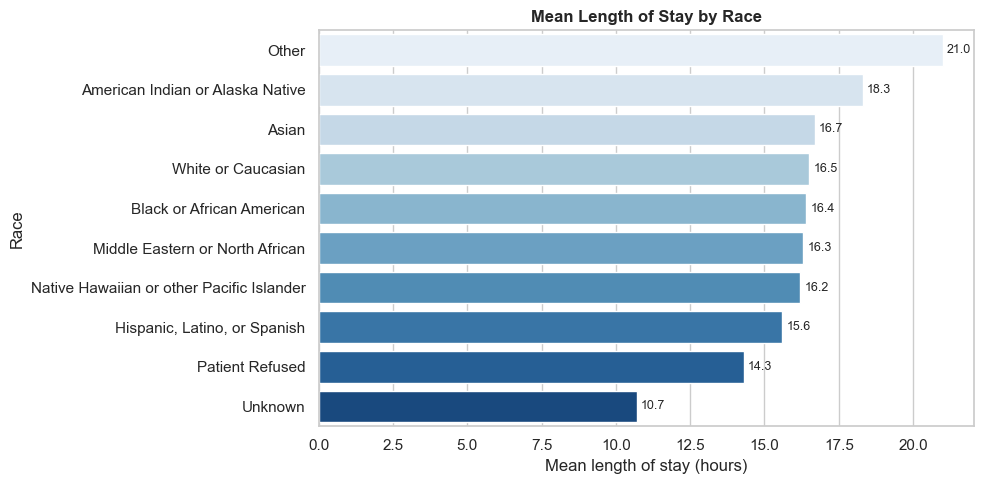

In [15]:
# Mean length of stay by race
race_dategap = (
    mergeEncountersPatients
    .dropna(subset=["dateGap", "FirstRace"])
    .groupby("FirstRace")
    .agg(encounters=("EncounterKey", "size"), mean_dateGap=("dateGap", "mean"), median_dateGap=("dateGap", "median"))
    .reset_index()
)
race_dategap["mean_dateGap"] = race_dategap["mean_dateGap"].round(1)
race_dategap["median_dateGap"] = race_dategap["median_dateGap"].round(1)
race_dategap = race_dategap.query("encounters >= 10").sort_values("mean_dateGap", ascending=False)

plt.figure(figsize=(10, max(5, 0.35 * len(race_dategap))))
colors = sns.color_palette("Blues", n_colors=max(len(race_dategap), 3))
ax = sns.barplot(data=race_dategap, y="FirstRace", x="mean_dateGap", palette=colors)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=9)
ax.set_title("Mean Length of Stay by Race", weight="bold")
ax.set_xlabel("Mean length of stay (hours)")
ax.set_ylabel("Race")
plt.tight_layout()
plt.show()


## 4.2 Demographics - Heatmap

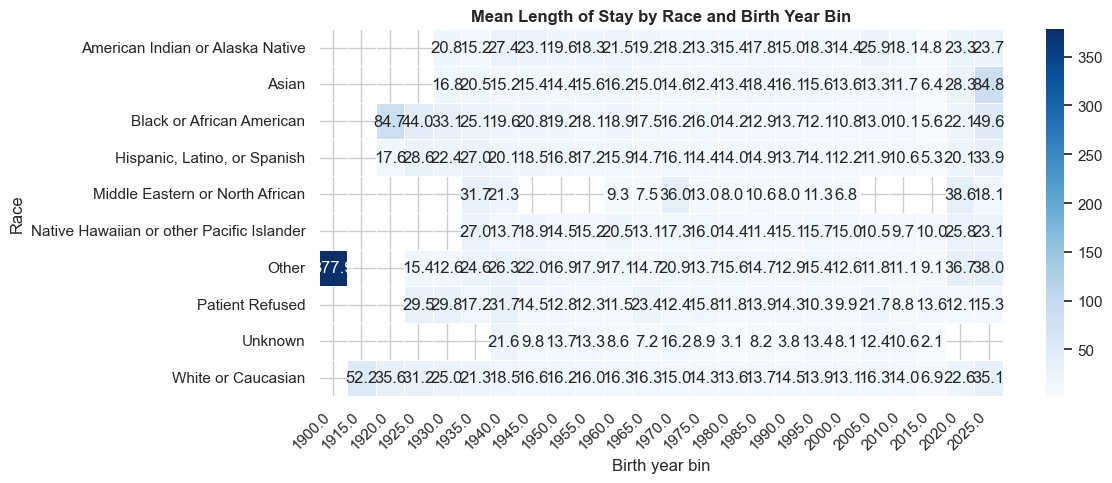

In [16]:
# Heatmap: race by birth year bin
heatmap_data = (
    mergeEncountersPatients
    .dropna(subset=["dateGap", "FirstRace", "PatientBirthYearBin"])
    .groupby(["FirstRace", "PatientBirthYearBin"])
    .agg(encounters=("EncounterKey", "size"), mean_dateGap=("dateGap", "mean"))
    .reset_index()
    .query("encounters >= 5")
)

pivot = heatmap_data.pivot(index="FirstRace", columns="PatientBirthYearBin", values="mean_dateGap")
plt.figure(figsize=(12, max(5, 0.35 * len(pivot))))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Blues", linewidths=0.5, linecolor="white")
plt.title("Mean Length of Stay by Race and Birth Year Bin", weight="bold")
plt.xlabel("Birth year bin")
plt.ylabel("Race")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 4.3 Behavioral - Smoking and Race

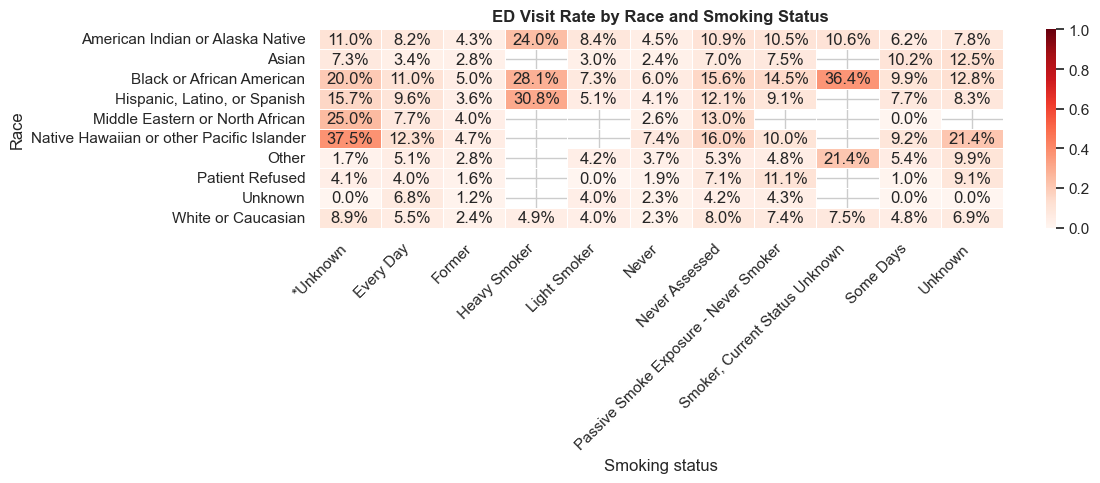

In [17]:
# Heatmap: ED visit rate by race and smoking status
smoking_df = mergeEncountersPatients.dropna(subset=["IsEdVisit_bool", "FirstRace", "SmokingStatus"]).copy()
smoking_heatmap = (
    smoking_df
    .groupby(["FirstRace", "SmokingStatus"])
    .agg(encounters=("EncounterKey", "size"), ed_rate=("IsEdVisit_bool", "mean"))
    .reset_index()
    .query("encounters >= 5")
)

pivot = smoking_heatmap.pivot(index="FirstRace", columns="SmokingStatus", values="ed_rate")
labels = pivot.map(lambda x: "" if pd.isna(x) else f"{x:.1%}")
plt.figure(figsize=(12, max(5, 0.35 * len(pivot))))
sns.heatmap(pivot, annot=labels, fmt="", cmap="Reds", linewidths=0.5, linecolor="white", vmin=0, vmax=1)
plt.title("ED Visit Rate by Race and Smoking Status", weight="bold")
plt.xlabel("Smoking status")
plt.ylabel("Race")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 4.4 Visit Gap Pattern

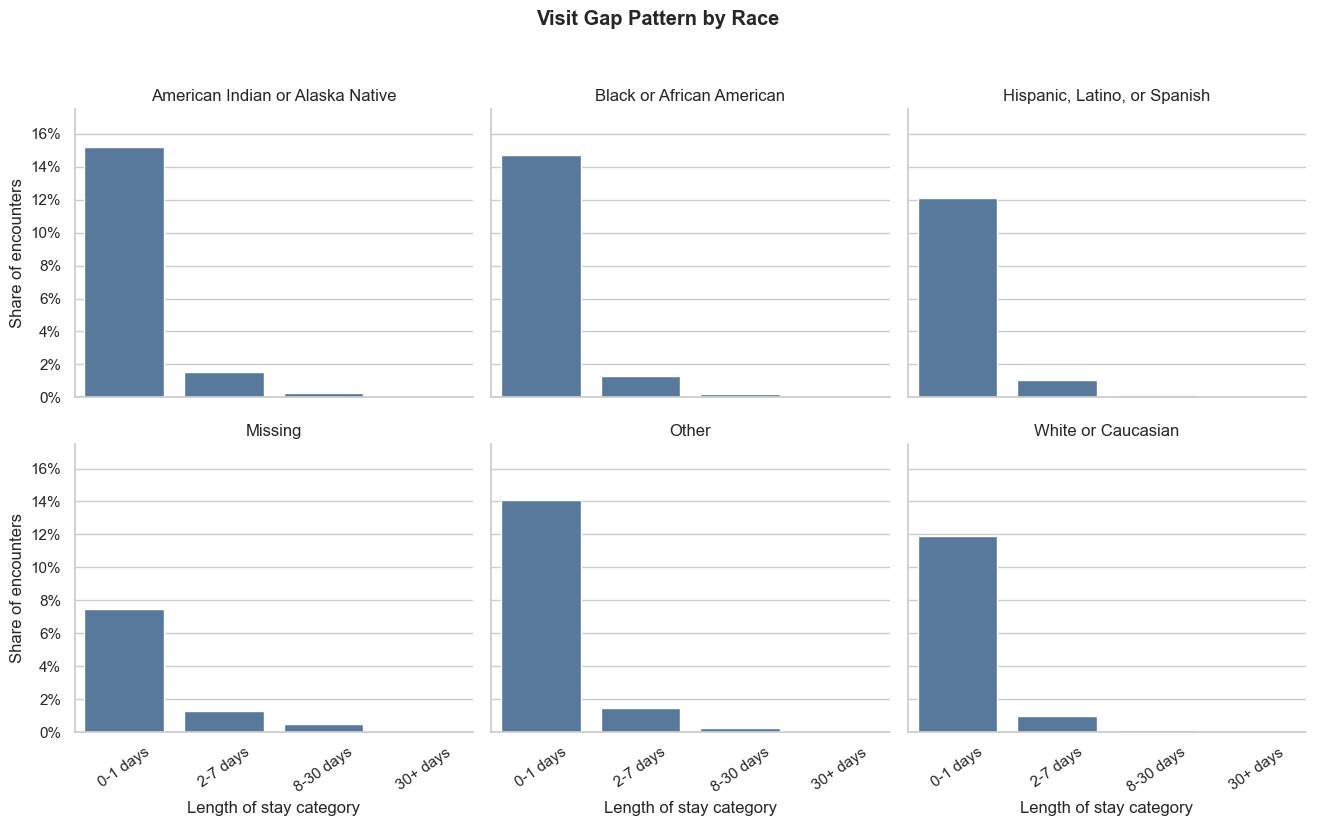

In [18]:
# Visit gap pattern
race_gap_data = mergeEncountersPatients.copy()
race_gap_data["dateGap_cat"] = pd.cut(
    race_gap_data["dateGapDays"],
    bins=[-np.inf, 1, 7, 30, np.inf],
    labels=["0-1 days", "2-7 days", "8-30 days", "30+ days"],
)
race_gap_data["dateGap_cat"] = race_gap_data["dateGap_cat"].astype(object).where(race_gap_data["dateGapDays"].notna(), "Missing")
race_gap_data["FirstRace"] = race_gap_data["FirstRace"].fillna("Missing")

race_gap_data = (
    race_gap_data
    .groupby(["FirstRace", "dateGap_cat"], dropna=False)
    .size()
    .reset_index(name="Visits")
)
race_gap_data["Percent"] = race_gap_data["Visits"] / race_gap_data.groupby("FirstRace")["Visits"].transform("sum")

top_races = (
    race_gap_data.groupby("FirstRace")["Visits"].sum().nlargest(6).index.tolist()
)
plot_gap = race_gap_data[race_gap_data["FirstRace"].isin(top_races) & (race_gap_data["dateGap_cat"] != "Missing")].copy()

order = ["0-1 days", "2-7 days", "8-30 days", "30+ days"]
g = sns.catplot(
    data=plot_gap,
    x="dateGap_cat", y="Percent", col="FirstRace",
    kind="bar", col_wrap=3, order=order,
    height=4, aspect=1.1, color="#4e79a7",
)
g.set_axis_labels("Length of stay category", "Share of encounters")
g.set_titles("{col_name}")
for ax in g.axes.flatten():
    ax.set_ylim(0, max(0.01, plot_gap["Percent"].max() * 1.15))
    ax.tick_params(axis="x", rotation=35)
    ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
g.fig.suptitle("Visit Gap Pattern by Race", weight="bold", y=1.03)
plt.tight_layout()
plt.show()


# 5. Geographic Analysis

## 5.1 Prep Local Geography Data

In [19]:
# Prep local geography data with real Census tract geometry
try:
    import geopandas as gpd
except ImportError as exc:
    raise ImportError(
        "Missing required package: geopandas. Install it in this notebook kernel with: %pip install geopandas"
    ) from exc

ks_tracts_url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_20_tract_500k.zip"
ks_tracts = (
    gpd.read_file(ks_tracts_url)
    [["GEOID", "geometry"]]
    .rename(columns={"GEOID": "CensusTract"})
    .to_crs("EPSG:4326")
)

departments_clean = departments[["CensusTract", "DepartmentName", "DepartmentType", "DepartmentSpecialty"]].drop_duplicates().copy()
departments_clean["CensusTract"] = departments_clean["CensusTract"].map(lambda x: clean_fips(x, width=11))
departments_clean = departments_clean[departments_clean["CensusTract"].str.slice(0, 2).eq("20").fillna(False)]

patients_by_tract = (
    mergeEncountersPatients
    .dropna(subset=["ageDiff", "CensusTract"])
    .query("VitalStatus == 'Alive'")
    .groupby("CensusTract")
    .agg(
        mean_ageDiff=("ageDiff", "mean"),
        median_ageDiff=("ageDiff", "median"),
        mean_dateGap=("dateGap", "mean"),
        total_patients=("PatientDurableKey", "nunique"),
    )
    .round({"mean_ageDiff": 1, "median_ageDiff": 1, "mean_dateGap": 1})
    .reset_index()
)

department_counts = departments_clean.groupby("CensusTract").size().reset_index(name="department_count")

map_patients = (
    tract_population
    .merge(patients_by_tract, on="CensusTract", how="left")
    .merge(department_counts, on="CensusTract", how="left")
)
map_patients["department_count"] = map_patients["department_count"].fillna(0).astype(int)

map_patients_sf = ks_tracts.merge(
    map_patients.drop(columns=["geometry"], errors="ignore"),
    on="CensusTract",
    how="left",
)
map_patients_sf["department_count"] = map_patients_sf["department_count"].fillna(0).astype(int)

map_summary = pd.DataFrame({
    "tracts": [len(map_patients_sf)],
    "tracts_with_patients": [map_patients_sf["total_patients"].notna().sum()],
    "tracts_with_departments": [(map_patients_sf["department_count"] > 0).sum()],
})
display(map_summary)


,tracts,tracts_with_patients,tracts_with_departments
0,829,539,31


## 5.2 Local Map-Like Views

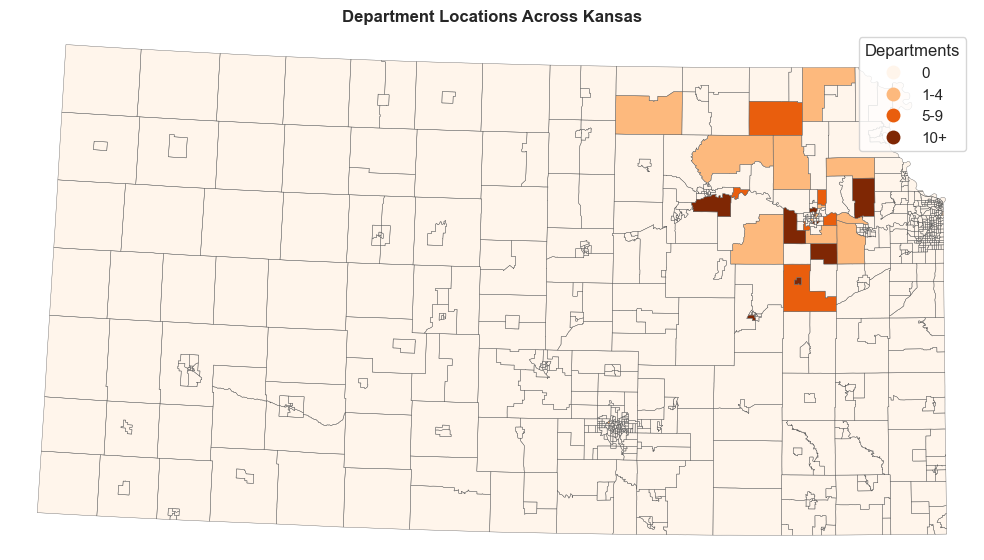

In [ ]:
# Department locations across Kansas
if "map_patients_sf" not in globals():
    raise RuntimeError("Run the 5.1 Prep Local Geography Data cell before running this map cell.")

department_bins = [-0.1, 0, 4, 9, np.inf]
department_labels = ["0", "1-4", "5-9", "10+"]
map_patients_sf = map_patients_sf.copy()
map_patients_sf["department_count_group"] = pd.cut(
    map_patients_sf["department_count"],
    bins=department_bins,
    labels=department_labels,
)

map_plot = map_patients_sf.to_crs("EPSG:5070")

fig, ax = plt.subplots(figsize=(10, 7))
map_plot.plot(
    column="department_count_group",
    ax=ax,
    cmap="Oranges",
    linewidth=0.08,
    edgecolor="#cccccc",
    legend=True,
    categorical=True,
    legend_kwds={"title": "Departments"},
)
map_plot.boundary.plot(ax=ax, color="#595959", linewidth=0.25)
minx, miny, maxx, maxy = map_plot.total_bounds
pad_x = (maxx - minx) * 0.03
pad_y = (maxy - miny) * 0.03
ax.set_xlim(minx - pad_x, max + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_title("Department Locations Across Kansas", weight="bold")
ax.set_axis_off()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


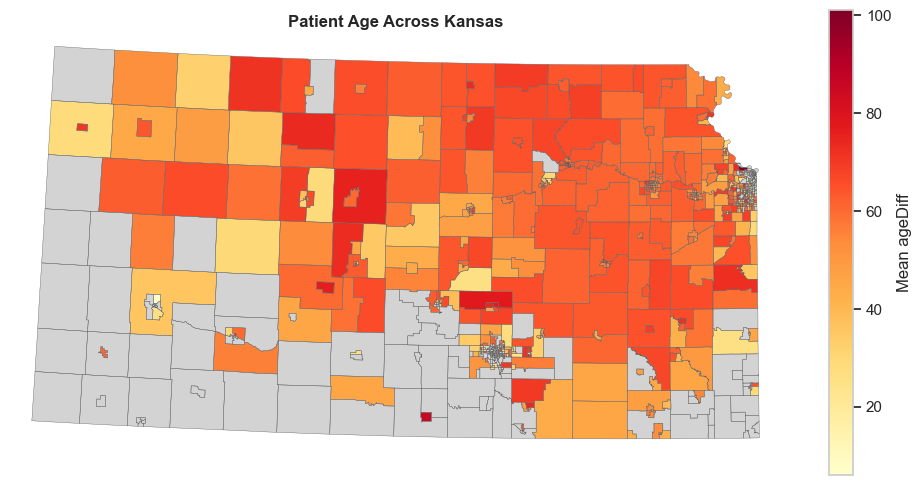

In [21]:
# Patient age difference across Kansas
if "map_patients_sf" not in globals():
    raise RuntimeError("Run the 5.1 Prep Local Geography Data cell before running this map cell.")

map_plot = map_patients_sf.to_crs("EPSG:5070")

fig, ax = plt.subplots(figsize=(10, 7))
map_plot.plot(
    column="mean_ageDiff",
    ax=ax,
    cmap="YlOrRd",
    linewidth=0.08,
    edgecolor="#cccccc",
    legend=True,
    legend_kwds={"label": "Mean ageDiff", "shrink": 0.7},
    missing_kwds={"color": "#d3d3d3", "label": "No patient data"},
)
map_plot.boundary.plot(ax=ax, color="#595959", linewidth=0.25)
minx, miny, maxx, maxy = map_plot.total_bounds
pad_x = (maxx - minx) * 0.03
pad_y = (maxy - miny) * 0.03
ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)
ax.set_title("Patient Age Across Kansas", weight="bold")
ax.set_axis_off()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


In [22]:
# Patient journey summary by region type
geography_summary = (
    mergeEncountersPatients
    .dropna(subset=["region_type", "dateGap", "journey_score"])
    .groupby("region_type")
    .agg(
        encounters=("EncounterKey", "size"),
        patients=("PatientDurableKey", "nunique"),
        mean_dateGap=("dateGap", "mean"),
        mean_ageDiff=("ageDiff", "mean"),
        mean_journey_score=("journey_score", "mean"),
        ed_rate=("IsEdVisit_bool", "mean"),
    )
    .reset_index()
    .sort_values("encounters", ascending=False)
)
geography_summary["mean_dateGap"] = geography_summary["mean_dateGap"].round(1)
geography_summary["mean_ageDiff"] = geography_summary["mean_ageDiff"].round(1)
geography_summary["mean_journey_score"] = geography_summary["mean_journey_score"].round(3)
geography_summary["ed_rate"] = geography_summary["ed_rate"].map(lambda x: f"{x:.1%}" if pd.notna(x) else np.nan)
display(geography_summary)


,region_type,encounters,patients,mean_dateGap,mean_ageDiff,mean_journey_score,ed_rate
2,Urban,736567,114839,15.6,60.2,0.857,20.7%
1,Suburban,6062,1283,18.5,60.2,0.848,23.8%
0,Rural,2,2,47.0,51.0,0.924,0.0%


## 5.4 County Gap Summary

In [32]:
# County-level access gap table
# Gap Score follows the requested table logic: mean age divided by available departments + 1.
from IPython.display import Markdown, display

if "mergeEncountersPatients" not in globals():
    raise RuntimeError(
        "Run the earlier data-loading and merge cells first: Libraries, Load data, Clean date gaps, "
        "and section 3.2 Merge data. Or use Kernel > Restart & Run All."
    )
if "departments" not in globals():
    raise RuntimeError("Run the Load data cell first so the departments table exists.")

display(Markdown(
    "**Gap Score** estimates where older patient populations may have less department access. "
    "It is calculated as **Age (mean) / (Departments + 1)**, so a higher score means the county has "
    "a higher average patient age relative to the number of available departments. The `+ 1` keeps "
    "counties with zero departments from causing a divide-by-zero error."
))

def clean_county_name(value):
    if pd.isna(value):
        return "Others"
    text = str(value).strip()
    if text.lower().replace("*", "") in {"", "unspecified", "unknown", "not specified"}:
        return "Others"
    return text

required_county_cols = {"County", "ageDiff", "EncounterKey", "PatientDurableKey"}
missing_county_cols = required_county_cols.difference(mergeEncountersPatients.columns)
if missing_county_cols:
    raise KeyError(f"Missing columns needed for county gap table: {sorted(missing_county_cols)}")

county_patient_data = mergeEncountersPatients.copy()
county_patient_data["County"] = county_patient_data["County"].map(clean_county_name)

county_patient_summary = (
    county_patient_data
    .dropna(subset=["ageDiff"])
    .query("VitalStatus == 'Alive'")
    .groupby("County")
    .agg(
        mean_age=("ageDiff", "mean"),
        encounters=("EncounterKey", "nunique"),
        patients=("PatientDurableKey", "nunique"),
    )
    .reset_index()
)

county_department_data = departments.copy()
county_department_data["County"] = county_department_data["County"].map(clean_county_name)

county_department_counts = (
    county_department_data
    .groupby("County")
    .agg(Departments=("DepartmentKey", "nunique"))
    .reset_index()
)

county_gap_table = (
    county_patient_summary
    .merge(county_department_counts, on="County", how="left")
    .assign(Departments=lambda df: df["Departments"].fillna(0).astype(int))
    .query("encounters >= 10")
)
county_gap_table["Gap Score"] = county_gap_table["mean_age"] / (county_gap_table["Departments"] + 1)
county_gap_table = (
    county_gap_table
    .rename(columns={"mean_age": "Age (mean)"})
    [["County", "Age (mean)", "Departments", "Gap Score", "encounters", "patients"]]
    .sort_values("Gap Score", ascending=False)
    .reset_index(drop=True)
)

county_gap_display = county_gap_table[["County", "Age (mean)", "Departments", "Gap Score"]].head(15)
styled_county_gap = (
    county_gap_display.style
    .hide(axis="index")
    .format({"Age (mean)": "{:.1f}", "Departments": "{:,.0f}", "Gap Score": "{:.1f}"})
    .background_gradient(subset=["Age (mean)", "Gap Score"], cmap="YlOrRd")
    .set_properties(subset=["County", "Departments"], **{"background-color": "white", "color": "black"})
    .set_caption("County access gap summary")
    .set_table_styles([
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "18px"), ("font-weight", "700"), ("color", "black"), ("padding", "8px 0 10px")]},
        {"selector": "th", "props": [("background-color", "#d9e2ec"), ("color", "black"), ("font-weight", "700"), ("text-align", "center"), ("padding", "10px")]},
        {"selector": "td", "props": [("padding", "9px 12px"), ("border-bottom", "1px solid #d9e2ec"), ("text-align", "center"), ("color", "black")]},
        {"selector": "td:first-child", "props": [("text-align", "left"), ("font-weight", "600")]},
        {"selector": "tbody tr:nth-child(even)", "props": [("background-color", "#f7fafc")]},
        {"selector": "table", "props": [("border-collapse", "collapse"), ("border", "1px solid #bcccdc"), ("border-radius", "8px"), ("overflow", "hidden"), ("font-family", "Arial, sans-serif")]},
    ])
)
display(styled_county_gap)

# Export the same table as a PNG image.
from matplotlib import colors as mcolors

png_table = county_gap_display.copy()
png_table["Age (mean)"] = png_table["Age (mean)"].map(lambda x: f"{x:.1f}")
png_table["Departments"] = png_table["Departments"].map(lambda x: f"{x:,.0f}")
png_table["Gap Score"] = png_table["Gap Score"].map(lambda x: f"{x:.1f}")

age_values = county_gap_display["Age (mean)"]
gap_values = county_gap_display["Gap Score"]
age_norm = mcolors.Normalize(vmin=age_values.min(), vmax=age_values.max())
gap_norm = mcolors.Normalize(vmin=gap_values.min(), vmax=gap_values.max())
heat_cmap = plt.get_cmap("YlOrRd")

fig_height = max(3.2, 0.38 * len(png_table) + 1.2)
fig, ax = plt.subplots(figsize=(8.5, fig_height))
ax.axis("off")
ax.set_title("County access gap summary", fontsize=16, fontweight="bold", color="black", pad=14)

table = ax.table(
    cellText=png_table.values,
    colLabels=png_table.columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.35)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("#bcccdc")
    cell.get_text().set_color("black")
    if row == 0:
        cell.set_facecolor("#d9e2ec")
        cell.get_text().set_weight("bold")
    elif col == 1:
        value = county_gap_display.iloc[row - 1]["Age (mean)"]
        cell.set_facecolor(heat_cmap(age_norm(value)))
    elif col == 3:
        value = county_gap_display.iloc[row - 1]["Gap Score"]
        cell.set_facecolor(heat_cmap(gap_norm(value)))
    else:
        cell.set_facecolor("white")

png_path = "county_gap_summary.png"
plt.tight_layout()
fig.savefig(png_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)
display(Markdown(f"Saved PNG export: `{png_path}`"))


**Gap Score** estimates where older patient populations may have less department access. It is calculated as **Age (mean) / (Departments + 1)**, so a higher score means the county has a higher average patient age relative to the number of available departments. The `+ 1` keeps counties with zero departments from causing a divide-by-zero error.

County,Age (mean),Departments,Gap Score
DOUGLAS,70.8,13,5.1
JEFFERSON,56.3,11,4.7
JACKSON,56.9,14,3.8
POTTAWATOMIE,59.3,16,3.5
OSAGE,57.4,26,2.1
LYON,56.8,39,1.4
RILEY,60.9,90,0.7
GEARY,49.5,494,0.1
Others,65.3,"5,368",0.0
SHAWNEE,58.6,"5,372",0.0


Saved PNG export: `county_gap_summary.png`

# 6. Regression Models

In [29]:
# Model data
def lump_top_n(series, n, other_label="Other"):
    counts = series.dropna().astype(str).value_counts()
    keep = set(counts.nlargest(n).index)
    return series.astype(object).where(series.astype(str).isin(keep) | series.isna(), other_label)

model_data = mergeEncountersPatients.copy()
model_data["FirstRace"] = lump_top_n(model_data["FirstRace"], 6)
model_data["SmokingStatus"] = lump_top_n(model_data["SmokingStatus"], 5)
model_data["MaritalStatus"] = lump_top_n(model_data["MaritalStatus"], 5)
model_data["AdmissionType"] = lump_top_n(model_data["AdmissionType"], 6)
model_data["VisitType"] = lump_top_n(model_data["VisitType"], 6)
model_data["region_type"] = model_data["region_type"].fillna("Unknown")
model_data["IsEdVisit"] = model_data["IsEdVisit_bool"]
model_data["IsInpatientAdmission"] = bool_series(model_data["IsInpatientAdmission"])

model_data = model_data[
    model_data["dateGap"].notna()
    & model_data["ageDiff"].notna()
    & model_data["journey_score"].notna()
    & (model_data["dateGap"] >= 0)
    & (model_data["region_type"] != "Unknown")
].copy()

model_data = model_data.sample(n=min(len(model_data), 100_000), random_state=2026)
display(pd.DataFrame({"rows_used_for_models": [len(model_data)]}))


,rows_used_for_models
0,100000


## 6.1 Linear Regression - Predict Length of Stay

In [25]:
# Linear regression: predict length of stay
if not HAS_STATSMODELS:
    raise ImportError("statsmodels is required for regression cells. Install statsmodels to run this section.")

lm_formula = "dateGap ~ C(FirstRace) + C(SmokingStatus) + C(MaritalStatus) + IsEdVisit + C(AdmissionType) + IsInpatientAdmission + C(VisitType) + ageDiff + C(region_type) + ageDiff:C(region_type)"
lm_model = smf.ols(lm_formula, data=model_data).fit()
print(lm_model.summary())

lm_significant = (
    pd.DataFrame({
        "term": lm_model.params.index,
        "estimate": lm_model.params.values,
        "std_error": lm_model.bse.values,
        "statistic": lm_model.tvalues.values,
        "p_value": lm_model.pvalues.values,
    })
    .query("p_value < 0.05")
)
lm_significant["direction"] = np.where(lm_significant["estimate"] > 0, "Increases dateGap", "Decreases dateGap")
lm_significant = lm_significant.assign(abs_estimate=lm_significant["estimate"].abs()).sort_values("abs_estimate", ascending=False).drop(columns="abs_estimate")
lm_significant["estimate"] = lm_significant["estimate"].round(4)
lm_significant["p_value"] = lm_significant["p_value"].round(4)
display(lm_significant)


                            OLS Regression Results                            
Dep. Variable:                dateGap   R-squared:                       0.321
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     1623.
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:15:17   Log-Likelihood:            -4.9358e+05
No. Observations:               99676   AIC:                         9.872e+05
Df Residuals:                   99646   BIC:                         9.875e+05
Df Model:                          29                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

,term,estimate,std_error,statistic,p_value,direction
22,IsInpatientAdmission[T.True],92.4863,0.544670,169.802486,0.0000,Increases dateGap
20,C(AdmissionType)[T.Trauma Center],79.2123,4.838798,16.370247,0.0000,Increases dateGap
18,C(AdmissionType)[T.Newborn],25.6281,1.719995,14.900085,0.0000,Increases dateGap
17,C(AdmissionType)[T.Emergency],13.9876,2.988779,4.680022,0.0000,Increases dateGap
21,C(AdmissionType)[T.Urgent],13.4854,1.051251,12.827955,0.0000,Increases dateGap
16,IsEdVisit[T.True],-10.3175,2.960156,-3.485460,0.0005,Decreases dateGap
23,C(VisitType)[T.FOLLOW UP],7.9086,0.904987,8.738866,0.0000,Increases dateGap
27,C(region_type)[T.Urban],-7.7954,3.471121,-2.245779,0.0247,Decreases dateGap
26,C(VisitType)[T.X-RAY VT],6.7531,1.475890,4.575607,0.0000,Increases dateGap
25,C(VisitType)[T.Other],5.6887,0.445404,12.771958,0.0000,Increases dateGap


## 6.2 Logistic Regression - Predict ED Visit

In [26]:
# Logistic regression: predict ED visit
logit_formula = "IsEdVisit ~ C(FirstRace) + C(MaritalStatus) + C(SmokingStatus) + C(AdmissionType) + ageDiff + C(region_type)"
logit_model = smf.logit(logit_formula, data=model_data).fit(maxiter=100, disp=False)
print(logit_model.summary())

logit_significant = pd.DataFrame({
    "term": logit_model.params.index,
    "estimate": logit_model.params.values,
    "std_error": logit_model.bse.values,
    "statistic": logit_model.tvalues.values,
    "p_value": logit_model.pvalues.values,
})
logit_significant["odds_ratio"] = np.exp(logit_significant["estimate"]).round(3)
logit_significant["p_value"] = logit_significant["p_value"].round(4)
logit_significant = logit_significant.query("p_value < 0.05").sort_values("odds_ratio", ascending=False)
display(logit_significant)


ValueError: endog has evaluated to an array with multiple columns that has shape (99676, 2). This occurs when the variable converted to endog is non-numeric (e.g., bool or str).

## 6.3 Journey Score Model

In [27]:
# Linear regression: journey score
journey_formula = "journey_score ~ ageDiff + C(region_type) + IsEdVisit + C(AdmissionType) + C(SmokingStatus) + C(MaritalStatus) + C(FirstRace) + ageDiff:C(region_type)"
lm_journey = smf.ols(journey_formula, data=model_data).fit()
print(lm_journey.summary())

journey_significant = (
    pd.DataFrame({
        "term": lm_journey.params.index,
        "estimate": lm_journey.params.values,
        "std_error": lm_journey.bse.values,
        "statistic": lm_journey.tvalues.values,
        "p_value": lm_journey.pvalues.values,
    })
    .query("p_value < 0.05")
)
journey_significant["direction"] = np.where(journey_significant["estimate"] > 0, "Improves score", "Worsens score")
journey_significant = journey_significant.assign(abs_estimate=journey_significant["estimate"].abs()).sort_values("abs_estimate", ascending=False).drop(columns="abs_estimate")
journey_significant["estimate"] = journey_significant["estimate"].round(4)
journey_significant["p_value"] = journey_significant["p_value"].round(4)
display(journey_significant)


                            OLS Regression Results                            
Dep. Variable:          journey_score   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.919
Method:                 Least Squares   F-statistic:                 4.709e+04
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:18:28   Log-Likelihood:             2.0694e+05
No. Observations:               99676   AIC:                        -4.138e+05
Df Residuals:                   99651   BIC:                        -4.136e+05
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

,term,estimate,std_error,statistic,p_value,direction
0,Intercept,1.0141,0.003216,315.283137,0.0000,Improves score
2,IsEdVisit[T.True],-0.2459,0.002625,-93.679191,0.0000,Worsens score
6,C(AdmissionType)[T.Trauma Center],-0.0178,0.004271,-4.176121,0.0000,Worsens score
7,C(AdmissionType)[T.Urgent],-0.0156,0.000793,-19.674433,0.0000,Worsens score
4,C(AdmissionType)[T.Newborn],-0.0125,0.001431,-8.728833,0.0000,Worsens score
3,C(AdmissionType)[T.Emergency],-0.0087,0.002631,-3.311804,0.0009,Worsens score
10,C(SmokingStatus)[T.Never Assessed],-0.0040,0.000666,-5.974729,0.0000,Worsens score
17,C(MaritalStatus)[T.Widowed],-0.0038,0.000435,-8.680967,0.0000,Worsens score
14,C(MaritalStatus)[T.Other],0.0030,0.000740,4.104599,0.0000,Improves score
16,C(MaritalStatus)[T.Single],-0.0019,0.000388,-4.792396,0.0000,Worsens score


# 7. Memory Management

In [ ]:
# Useful pattern for large data work. Run manually if needed.
# del large_object
# gc.collect()

# Optional: write a compact CSV snapshot for smaller follow-up work.
# mergeEncountersPatients[["EncounterKey", "PatientDurableKey", "dateGap", "FirstRace"]].to_csv(
#     "mergeEncountersPatients_small.csv",
#     index=False,
# )


# 8. Conclusions

In [ ]:
# Conclusions
top_gap = (
    mergeEncountersPatients
    .dropna(subset=["FirstRace", "dateGap"])
    .groupby("FirstRace")
    .agg(encounters=("EncounterKey", "size"), mean_dateGap=("dateGap", "mean"))
    .reset_index()
    .query("encounters >= 10")
    .sort_values("mean_dateGap", ascending=False)
    .head(1)
)

top_region = (
    mergeEncountersPatients
    .dropna(subset=["region_type", "journey_score"])
    .query("region_type != 'Unknown'")
    .groupby("region_type")
    .agg(mean_journey_score=("journey_score", "mean"))
    .reset_index()
    .sort_values("mean_journey_score", ascending=False)
    .head(1)
)

top_gap_name = "Not available" if top_gap.empty else top_gap.iloc[0]["FirstRace"]
top_region_name = "Not available" if top_region.empty else top_region.iloc[0]["region_type"]

print(f"""
Key Findings
---------------------------------------------
1. Length of stay differs across clinical and demographic groups.
2. ED visits are included as both an outcome and a journey-score penalty.
3. Geography uses local tract centroid and population data from tigercensuscodes.csv.
4. Highest mean length-of-stay race group with at least 10 encounters: {top_gap_name}.
5. Highest average journey-score region: {top_region_name}.
---------------------------------------------
""")


*Report generated with Python after running the notebook cells.*